# Прогнозирование цены

### Задача
Целевая переменная — `price`. У вас есть 4 атрибута, и, очевидно, мы хотим, чтобы вы построили некую модель машинного обучения, которая прогнозирует цены.

1. Проведите первоначальный анализ данных.
2. Используйте ML модель и кратко объясните свой выбор.
3. Покажите точность вашей модели и прокомментируйте результаты.
4. Представьте нам результаты и шаги, которые вы предприняли, а также некоторые критические размышления.
5. Визуализируйте на графиках точность модели, важность признаков и корреляцию признаков с ценой.  

### Описание данных
Данные представлены в файле `price_sample.csv`.

### Комментарии

Определите, обучите и оцените прогнозирующую модель, которая принимает в качестве входных данных предоставленные данные. По вашему усмотрению вы можете разделить данные на наборы для обучения, тестирования. 

Убедитесь, что решение отражает весь ваш мыслительный процесс (для каждой ячейки кода оставляйте комментарии, иначе мы не поймем, что вы хотели сделать)

### Что мы точно хотим увидеть в вашей работе?

1. **Анализ данных**: Проведение первичного анализа данных для понимания их структуры и основных характеристик. 

2. **Обработка данных**: Это критически важный шаг, который включает в себя очистку данных, обработку пропущенных значений и дубликатов.

3. **Оценка модели**: Обучение и тестирование подходящей модели и оценка ее производительности с использованием релевантных метрик.

4. **Визуализация**: Постройте графики, которые покажут точность модели, важность признаков и корреляцию признаков с ценой. 

## 1. Загрузка данных и первичный анализ данных

Загрузка данных и первичный анализ данных используя методы Pandas *info()* и *describe()*.

In [79]:
import pandas as pd

prices = pd.read_csv('price_sample.csv')
prices

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50
...,...,...,...,...,...
9998,3,386.0,5000.0,12.0,460.00
9999,1,386.0,3250.0,8.0,325.00
10000,0,190.0,8856.0,5.6,133.33
10001,3,717.0,5000.0,13.6,820.00


In [81]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB


In [83]:
prices.describe()

,para1,para2,para3,para4,price
count,10003.000000,9997.000000,10003.000000,9998.000000,10003.000000
mean,1.380986,447.270681,9547.975527,8.458024,433.774924
std,3.500408,220.913801,8022.286943,4.613645,277.443154
min,0.000000,16.000000,200.000000,1.000000,50.730000
25%,1.000000,301.000000,2899.500000,4.000000,250.000000
50%,1.000000,434.000000,6446.000000,7.200000,370.000000
75%,1.000000,582.000000,15000.000000,13.600000,550.000000
max,337.000000,2554.000000,34782.000000,27.200000,5700.000000


## 2. Обработка данных

### Удаление дубликатов

In [87]:
prices = prices.drop(prices[prices.duplicated()].index)
prices

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50
...,...,...,...,...,...
9998,3,386.0,5000.0,12.0,460.00
9999,1,386.0,3250.0,8.0,325.00
10000,0,190.0,8856.0,5.6,133.33
10001,3,717.0,5000.0,13.6,820.00


### Обработка **Null** значений

In [90]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9788 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   9788 non-null   int64  
 1   para2   9782 non-null   float64
 2   para3   9788 non-null   float64
 3   para4   9783 non-null   float64
 4   price   9788 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 458.8 KB


In [92]:
print(f"Number of rows having at least one null values: {(prices.isnull().sum(axis = 1) > 0).sum()}")

Number of rows having at least one null values: 10


Учитывая, что по сравнению с общим количеством уникальных строк, количество строк с хотя бы одним Null значением всего лишь 10, их можно спокойно удалить.

In [95]:
prices.drop(prices[(prices.isnull().sum(axis = 1) > 0)].index, inplace = True)
prices

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50
...,...,...,...,...,...
9998,3,386.0,5000.0,12.0,460.00
9999,1,386.0,3250.0,8.0,325.00
10000,0,190.0,8856.0,5.6,133.33
10001,3,717.0,5000.0,13.6,820.00


## Выбор модели, обучение, и оценка

Так как таргет значение цены является непрерывным значением, нужно использовать Линейную Регрессию. Так как у нас признакми с очень разными масштабами, будем делать стандартизацию данных, чтобы признаки с большим масштабом не мешали процессу обучения модели, затемняя признаки с меньшим масштабом.

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = prices.loc[:, prices.columns != 'price']
y = prices['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error of this model on the test data: {mse:.4f}")
print(f"Mean absolute error of this model on the test data: {mae:.4f}")
print(f"R squared of this model on the test data: {r2:.4f}")

Mean squared error of this model on the test data: 32217.8764
Mean absolute error of this model on the test data: 115.2377
R squared of this model on the test data: 0.5338


## Визуализации

Корреляции между признаками и ценой:

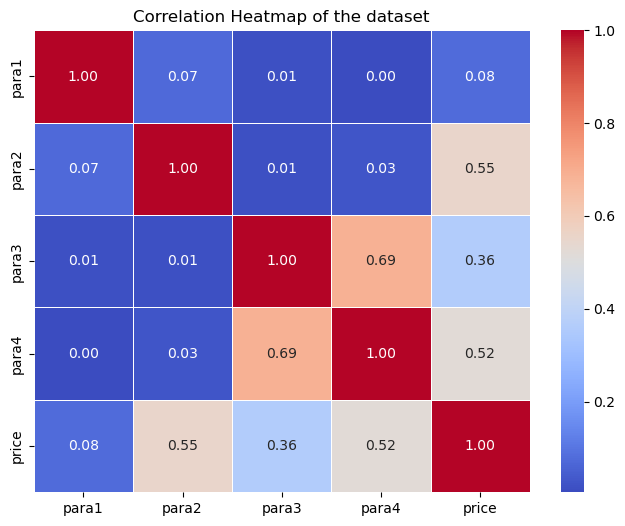

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = prices.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of the dataset')
plt.show()

Как видно, между признаками и ценой есть корреляции, однако корреляция с признаком "Para1" очень маленькая. Возможно, признак "Para1" не является важным признаком, учитывая что используется модель Линейной Регрессии (корреляция оценивает линейную связь между признаком "Para1" и ценой). Также, между признаками почти нет корреляции кроме как между признаками "Para3" и "Para4". Возможно, стоит предпринять какой-нибудь метод чтоб удоствериться стоит ли убрать один из них.

In [111]:
# Источник: https://www.datacamp.com/tutorial/sklearn-linear-regression

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Feature"] = X.columns

vif_vals = []
for i in range(X.shape[1]):
    vif_vals.append(variance_inflation_factor(X.values, i))

vif['VIF'] = vif_vals

print("Variance Inflation Factor (VIF) for each feature:")
print(vif)

Variance Inflation Factor (VIF) for each feature:
  Feature       VIF
0   para1  1.152144
1   para2  2.766021
2   para3  4.503773
3   para4  6.365782


Согласно источнику, учитывая что VIF > 5 для признака "Para4", возможно стоит удалить признак и попробовать натренировать модель заново и посмотреть есть ли улучшения. В целом, так как модель не тяжелая можно будет попробовать все комбинации признаков и посмотреть на метрики, тем самым сделать проинформированный выбор признаков.

In [118]:
from itertools import combinations  

features = list(range(X.shape[1]))
metrics = []

subsets = [list(subset) for tuples in ( list(combinations(features, k)) for k in range(1,len(features)+1) ) for subset in tuples]
for feats in subsets:
    X = prices.drop('price', axis = 1)
    X = X.iloc[:, feats]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
    
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    metrics.append([list(prices.columns[feats]), mse, mae, r2])
    
metrics_df = pd.DataFrame(metrics, columns = ['Features', 'MSE', 'MAE', 'R2']).sort_values(by = ['R2', 'MSE', 'MAE'], ascending = False)
metrics_df

,Features,MSE,MAE,R2
14,"[para1, para2, para3, para4]",32217.876361,115.237697,0.533794
11,"[para1, para2, para4]",32223.105906,115.241062,0.533719
13,"[para2, para3, para4]",32269.527323,115.298232,0.533047
8,"[para2, para4]",32276.893842,115.302960,0.532940
10,"[para1, para2, para3]",41092.197136,139.143196,0.405379
7,"[para2, para3]",41130.834610,139.160762,0.404820
6,"[para1, para4]",49349.838858,141.244003,0.285888
12,"[para1, para3, para4]",49353.871498,141.239815,0.285829
3,[para4],49794.878578,141.717368,0.279448
9,"[para3, para4]",49800.206140,141.731200,0.279371


Как видно, если убрать признак "Para4", из мерок оценки улучшилось только *МАЕ*, следовательно будет лучше оставить признак "Para4" в модели. В общем, лучшие метрики получается если использовать все признаки. Однако как и ожидалось, учитывая использование модели Линейная Регрессия и то что  признак "Para1" почти не показал никакую линейную корреляцию с ценой, убрав этот признак, мы получаем почти такие же показатели метрик, если бы использовали все признаки. Еще интереснее тот факт, что несмотря на более сильную корреляцию признака "Para3" с ценой, убрав ее мы получаем слегка приближенные значения метрик к тем если бы мы использовали все метрики. Используя только признаки "Para2" и "Para4", которые имели более высокую линейную корреляцию с ценой, мы получаем значения *R2* ниже лишь на **0.000854** и весьма сопоставимые значения *MSE* и *MAE*. В целях упрощения модели и чтобы сделать ее более обобщаемой, признаки "Para1" и "Para3" убраны. 

Также можно посмотреть на коэффиценты признаков в модели, используя все признаки чтобы дальше убедиться в важности определенных признаков.

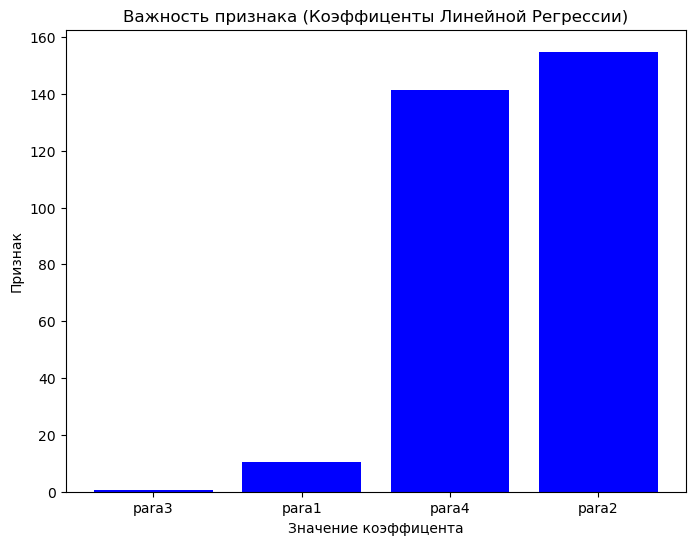

In [126]:
# Источник: https://www.datacamp.com/tutorial/sklearn-linear-regression
X = prices.drop('price', axis = 1)
y = prices['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coeffs = pd.DataFrame({'Feature': X.columns, 'Feature coefficient': model.coef_}).sort_values(by = 'Feature coefficient', ascending = True)

plt.figure(figsize = (8, 6))
plt.bar(coeffs["Feature"], coeffs['Feature coefficient'], color="blue")
plt.xlabel("Значение коэффицента")
plt.ylabel("Признак")
plt.title("Важность признака (Коэффиценты Линейной Регрессии)")
plt.show()

Как видно, по сравнению с признаками "Para2" и "Para4" коэффиценты признаком "Para1" и "Para3" очень малы и не составляют существенного веса при предсказывании цены в модели Линейной Регрессии, следовательно, мы убираем эти признаки.

Mean squared error of this model on the test data: 32276.8938
Mean absolute error of this model on the test data: 115.3030
R squared of this model on the test data: 0.5329


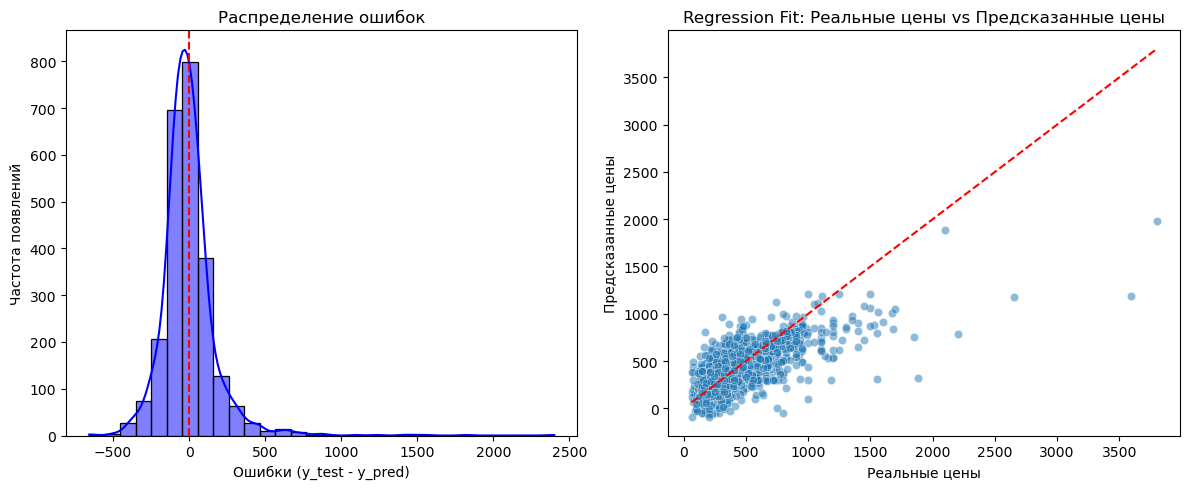

In [150]:
# Источник: https://www.datacamp.com/tutorial/sklearn-linear-regression
# Высчитывание ошибки.
errors = y_test - y_pred

X = prices.drop(['para1', 'para3', 'price'], axis = 1)
y = prices['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error of this model on the test data: {mse:.4f}")
print(f"Mean absolute error of this model on the test data: {mae:.4f}")
print(f"R squared of this model on the test data: {r2:.4f}")

plt.figure(figsize = (12, 5))
# График 1: Распределение ошибок.
plt.subplot(121)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Распределение ошибок")
plt.xlabel("Ошибки (y_test - y_pred)")
plt.ylabel("Частота появлений")

# График 2: Regression Fit (Реальные цены vs Предсказанные цены).
plt.subplot(122)
sns.scatterplot(x = y_test, y = y_pred, alpha = 0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = 'red', linestyle='--') # Линия лучшего соответствия
plt.title("Regression Fit: Реальные цены vs Предсказанные цены")
plt.xlabel("Реальные цены")
plt.ylabel("Предсказанные цены")

plt.tight_layout()
plt.show()

В целом, мы получили оптимальное значение R2, хотя значения MSE и MAE могут показаться большими учитывая натуру таргетового значения (цена). Но в целом MAE = 115.3 выглядит весьма неплохим. Так же по распределениям ошибок, видно что наибольшее количество ошибок приходится на район возле значения 0, что показывает весьма хорошую предсказывательную способность модели.

**Замечание:** Также были испробованы методы Лог-трансформации таргетового значения, Регуляризованная линейная регрессия (Ридж, Лассо) (при ассистировании Chat-GPT), однако существенных улучшений в метриках не наблюдалось, поэтому эта модель была выбрана самой оптимальной в контексте этого мини-проекта.